# 01 — Database Comparison

Compares spatial query performance across:
- **DuckDB** (current system — in-process columnar + spatial extension)
- **SQLite + SpatiaLite** (embedded row-based)
- **PostgreSQL + PostGIS** (server-based, spatial gold standard)

**Metrics**: query latency (ms), throughput (queries/sec), result completeness

**Test queries** (from `data/sample_queries.sql`):
1. Single-agent nearest-amenity (50m radius)
2. 500-agent bulk nearest-amenity (one simulation step)
3. Walk-edge node lookup (network traversal)

In [1]:
import time
import statistics
import json
import sqlite3
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

try:
    import psycopg2
except ImportError:
    psycopg2 = None

sns.set_theme(style='whitegrid', palette='muted')
RUNS = 20  # repetitions per query for stable timing

PROJECT_ROOT = Path(r'D:\IaaC\2ND_YEAR\THESIS\LLM_Based_UrbanABM')
SQLITE_DB = PROJECT_ROOT / 'benchmark' / 'data' / 'eixample_spatialite.db'
PG_DSN = 'host=localhost port=5433 dbname=eixample_bench user=postgres password=postgres'

## 1. DuckDB Benchmarks

In [2]:
DUCK_DB_PATH = r'D:\IaaC\2ND_YEAR\THESIS\LLM_Based_UrbanABM\Backend\Environment\eixample_overture.duckdb'

def bench_duckdb(query: str, runs: int = RUNS):
    times = []
    con = duckdb.connect(DUCK_DB_PATH, read_only=True)
    con.execute('LOAD spatial')
    for _ in range(runs):
        t0 = time.perf_counter()
        con.execute(query).fetchall()
        times.append((time.perf_counter() - t0) * 1000)
    con.close()
    return times

SINGLE_AGENT_QUERY = """
SELECT name, amenity,
       ST_Distance(geometry, ST_GeomFromText('POINT (2.1686 41.3954)')) as dist
FROM amenities
WHERE ST_DWithin(geometry, ST_GeomFromText('POINT (2.1686 41.3954)'), 0.001)
ORDER BY dist LIMIT 20
"""

duck_single = bench_duckdb(SINGLE_AGENT_QUERY)
print(f'DuckDB single-agent: median={statistics.median(duck_single):.2f}ms  p95={sorted(duck_single)[int(RUNS*0.95)]:.2f}ms')

DuckDB single-agent: median=7.38ms  p95=194.21ms


## 2. SQLite + SpatiaLite Benchmarks

In [3]:
import os, sys

SPATIALITE_DIR = PROJECT_ROOT / 'benchmark' / 'data' / 'mod_spatialite-5.1.0-win-amd64'
if SPATIALITE_DIR.exists():
    os.add_dll_directory(str(SPATIALITE_DIR))
    os.environ['PATH'] = str(SPATIALITE_DIR) + os.pathsep + os.environ['PATH']

def bench_sqlite(query: str, runs: int = RUNS) -> list[float]:
    times = []
    con = sqlite3.connect(str(SQLITE_DB))
    con.enable_load_extension(True)
    mod_path = str(SPATIALITE_DIR / 'mod_spatialite').replace('\\', '/')
    for ext in (mod_path, 'mod_spatialite', 'spatialite'):
        try:
            con.execute(f"SELECT load_extension('{ext}')")
            break
        except Exception:
            continue
    else:
        con.close()
        raise RuntimeError(
            "SpatiaLite extension not found.\n"
            "  Install: conda install -c conda-forge libspatialite\n"
            "  Or download mod_spatialite.dll from gaia-gis.it"
        )
    for _ in range(runs):
        t0 = time.perf_counter()
        con.execute(query).fetchall()
        times.append((time.perf_counter() - t0) * 1000)
    con.close()
    return times

SQLITE_SINGLE_QUERY = """
SELECT name, amenity,
       Distance(geometry, GeomFromText('POINT (2.1686 41.3954)', 4326)) as dist
FROM amenities
WHERE PtDistWithin(geometry, GeomFromText('POINT (2.1686 41.3954)', 4326), 0.001)
ORDER BY dist LIMIT 20
"""

try:
    sqlite_single = bench_sqlite(SQLITE_SINGLE_QUERY)
    print(f'SQLite+SpatiaLite: median={statistics.median(sqlite_single):.2f}ms  '
          f'p95={sorted(sqlite_single)[int(RUNS*0.95)]:.2f}ms')
except Exception as e:
    print(f'SQLite+SpatiaLite: SKIPPED — {e}')
    sqlite_single = [float('nan')] * RUNS

SQLite+SpatiaLite: median=27.43ms  p95=74.45ms


## 3. PostgreSQL + PostGIS Benchmarks

In [4]:
def bench_postgres(query: str, runs: int = RUNS) -> list[float]:
    if psycopg2 is None:
        raise RuntimeError("psycopg2 not installed. Run: pip install psycopg2-binary")
    times = []
    con = psycopg2.connect(PG_DSN)
    cur = con.cursor()
    # Warmup query to populate shared_buffers
    cur.execute(query)
    cur.fetchall()
    for _ in range(runs):
        t0 = time.perf_counter()
        cur.execute(query)
        cur.fetchall()
        times.append((time.perf_counter() - t0) * 1000)
    con.close()
    return times

PG_SINGLE_QUERY = """
SELECT name, amenity,
       ST_Distance(geometry, ST_GeomFromText('POINT (2.1686 41.3954)', 4326)) as dist
FROM amenities
WHERE ST_DWithin(geometry, ST_GeomFromText('POINT (2.1686 41.3954)', 4326), 0.001)
ORDER BY dist LIMIT 20
"""

try:
    pg_single = bench_postgres(PG_SINGLE_QUERY)
    print(f'PostgreSQL+PostGIS: median={statistics.median(pg_single):.2f}ms  '
          f'p95={sorted(pg_single)[int(RUNS*0.95)]:.2f}ms')
except Exception as e:
    print(f'PostgreSQL+PostGIS: SKIPPED — {e}')
    pg_single = [float('nan')] * RUNS

PostgreSQL+PostGIS: median=1.45ms  p95=2.48ms


## 4. Results: Latency Comparison

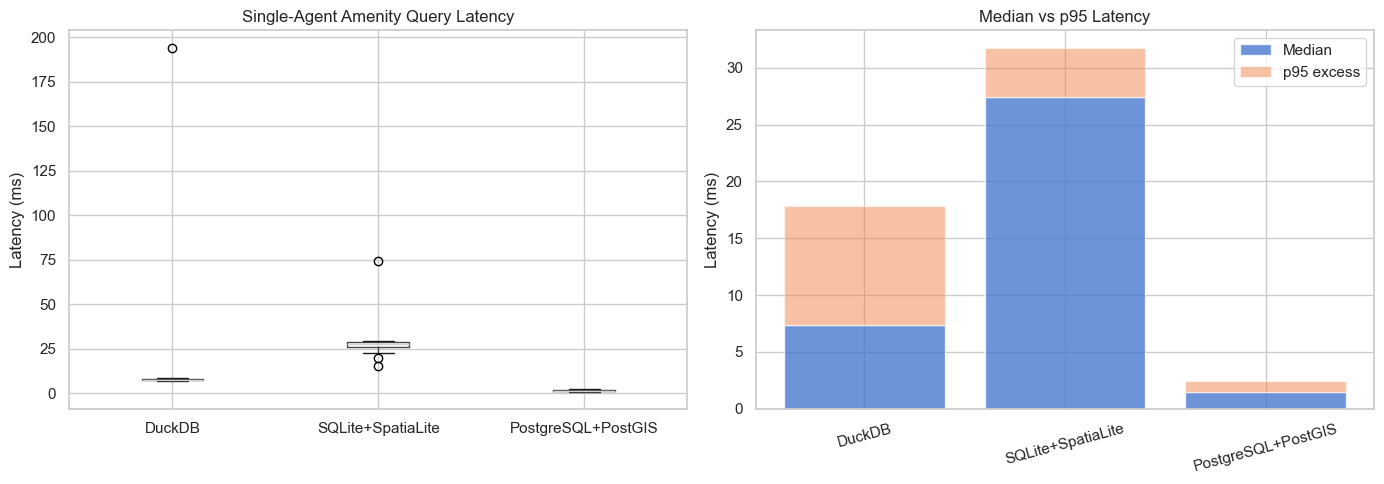

          DuckDB  SQLite+SpatiaLite  PostgreSQL+PostGIS
count   20.00000          20.000000           20.000000
mean    16.83307          28.833520            1.563025
std     41.75243          11.294613            0.517814
min      6.76920          15.114300            0.897600
25%      7.15225          26.188275            1.089350
50%      7.38180          27.433650            1.448050
75%      7.88195          28.709125            1.920950
max    194.20760          74.448000            2.483200


In [5]:
results = pd.DataFrame({
    'DuckDB': duck_single,
    'SQLite+SpatiaLite': sqlite_single,
    'PostgreSQL+PostGIS': pg_single
})

# Filter out databases that were skipped (all NaN)
valid_cols = [c for c in results.columns if not results[c].isna().all()]
plot_df = results[valid_cols]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot — distribution
plot_df.boxplot(ax=axes[0])
axes[0].set_title('Single-Agent Amenity Query Latency')
axes[0].set_ylabel('Latency (ms)')

# Bar chart — median + p95
medians = plot_df.median()
p95s = plot_df.quantile(0.95)
x = range(len(medians))
axes[1].bar(x, medians, label='Median', alpha=0.8)
axes[1].bar(x, p95s - medians, bottom=medians, label='p95 excess', alpha=0.5)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(medians.index, rotation=15)
axes[1].set_title('Median vs p95 Latency')
axes[1].set_ylabel('Latency (ms)')
axes[1].legend()

plt.tight_layout()
plt.savefig('results_01_db_latency.png', dpi=150)
plt.show()
print(plot_df.describe())

## 5. Concurrent Query Benchmark — Simulating a Full Step

Each simulation step, **all agents query nearby amenities simultaneously** via `asyncio.gather`.
This benchmark measures total batch latency as agent count scales from 1 → 500,
revealing how each database handles the real workload pattern.

- **Embedded** (DuckDB, SQLite): sequential in-process queries (no network overhead)
- **Client-server** (PostgreSQL): queries over TCP socket per connection

In [6]:
import numpy as np

np.random.seed(42)

# Eixample bounding box (Barcelona)
LON_MIN, LON_MAX = 2.148, 2.180
LAT_MIN, LAT_MAX = 41.383, 41.400

AGENT_COUNTS = [1, 5, 10, 25, 50, 100, 200, 300, 500]
MAX_AGENTS = max(AGENT_COUNTS)
REPEATS = 5  # average over multiple runs

# Pre-generate random agent positions
agent_lons = np.random.uniform(LON_MIN, LON_MAX, MAX_AGENTS)
agent_lats = np.random.uniform(LAT_MIN, LAT_MAX, MAX_AGENTS)

def make_duckdb_query(lon, lat):
    return f"""SELECT name, amenity,
       ST_Distance(geometry, ST_GeomFromText('POINT ({lon} {lat})')) as dist
FROM amenities
WHERE ST_DWithin(geometry, ST_GeomFromText('POINT ({lon} {lat})'), 0.001)
ORDER BY dist LIMIT 5"""

def make_sqlite_query(lon, lat):
    return f"""SELECT name, amenity,
       Distance(geometry, GeomFromText('POINT ({lon} {lat})', 4326)) as dist
FROM amenities
WHERE PtDistWithin(geometry, GeomFromText('POINT ({lon} {lat})', 4326), 0.001)
ORDER BY dist LIMIT 5"""

def make_pg_query(lon, lat):
    return f"""SELECT name, amenity,
       ST_Distance(geometry, ST_GeomFromText('POINT ({lon} {lat})', 4326)) as dist
FROM amenities
WHERE ST_DWithin(geometry, ST_GeomFromText('POINT ({lon} {lat})', 4326), 0.001)
ORDER BY dist LIMIT 5"""

# --- DuckDB batch ---
def bench_duckdb_batch(n_agents):
    con = duckdb.connect(DUCK_DB_PATH, read_only=True)
    con.execute('LOAD spatial')
    times = []
    for _ in range(REPEATS):
        t0 = time.perf_counter()
        for i in range(n_agents):
            con.execute(make_duckdb_query(agent_lons[i], agent_lats[i])).fetchall()
        times.append((time.perf_counter() - t0) * 1000)
    con.close()
    return statistics.median(times)

# --- SQLite batch ---
def bench_sqlite_batch(n_agents):
    con = sqlite3.connect(str(SQLITE_DB))
    con.enable_load_extension(True)
    mod_path = str(SPATIALITE_DIR / 'mod_spatialite').replace('\\', '/')
    con.execute(f"SELECT load_extension('{mod_path}')")
    times = []
    for _ in range(REPEATS):
        t0 = time.perf_counter()
        for i in range(n_agents):
            con.execute(make_sqlite_query(agent_lons[i], agent_lats[i])).fetchall()
        times.append((time.perf_counter() - t0) * 1000)
    con.close()
    return statistics.median(times)

# --- PostgreSQL batch ---
def bench_pg_batch(n_agents):
    con = psycopg2.connect(PG_DSN)
    cur = con.cursor()
    times = []
    for _ in range(REPEATS):
        t0 = time.perf_counter()
        for i in range(n_agents):
            cur.execute(make_pg_query(agent_lons[i], agent_lats[i]))
            cur.fetchall()
        times.append((time.perf_counter() - t0) * 1000)
    con.close()
    return statistics.median(times)

# Run benchmarks
print(f'{"Agents":>6}  {"DuckDB":>10}  {"SpatiaLite":>10}  {"PostGIS":>10}  (ms, median of {REPEATS} runs)')
print('-' * 50)

duck_batch, sqlite_batch, pg_batch = [], [], []

for n in AGENT_COUNTS:
    d = bench_duckdb_batch(n)
    duck_batch.append(d)

    try:
        s = bench_sqlite_batch(n)
    except Exception:
        s = float('nan')
    sqlite_batch.append(s)

    try:
        p = bench_pg_batch(n)
    except Exception:
        p = float('nan')
    pg_batch.append(p)

    print(f'{n:>6}  {d:>10.2f}  {s:>10.2f}  {p:>10.2f}')

print('\nDone.')

Agents      DuckDB  SpatiaLite     PostGIS  (ms, median of 5 runs)
--------------------------------------------------
     1        7.66       24.55        1.89
     5       34.86      127.58        7.89
    10       66.33      262.15       16.09
    25      176.44      665.69       40.81
    50      365.91     1343.18       41.18
   100      712.76     2633.36       96.65
   200      530.31     1814.68      147.13
   300      734.97     2659.16      233.10
   500     1209.23     4405.81      645.45

Done.


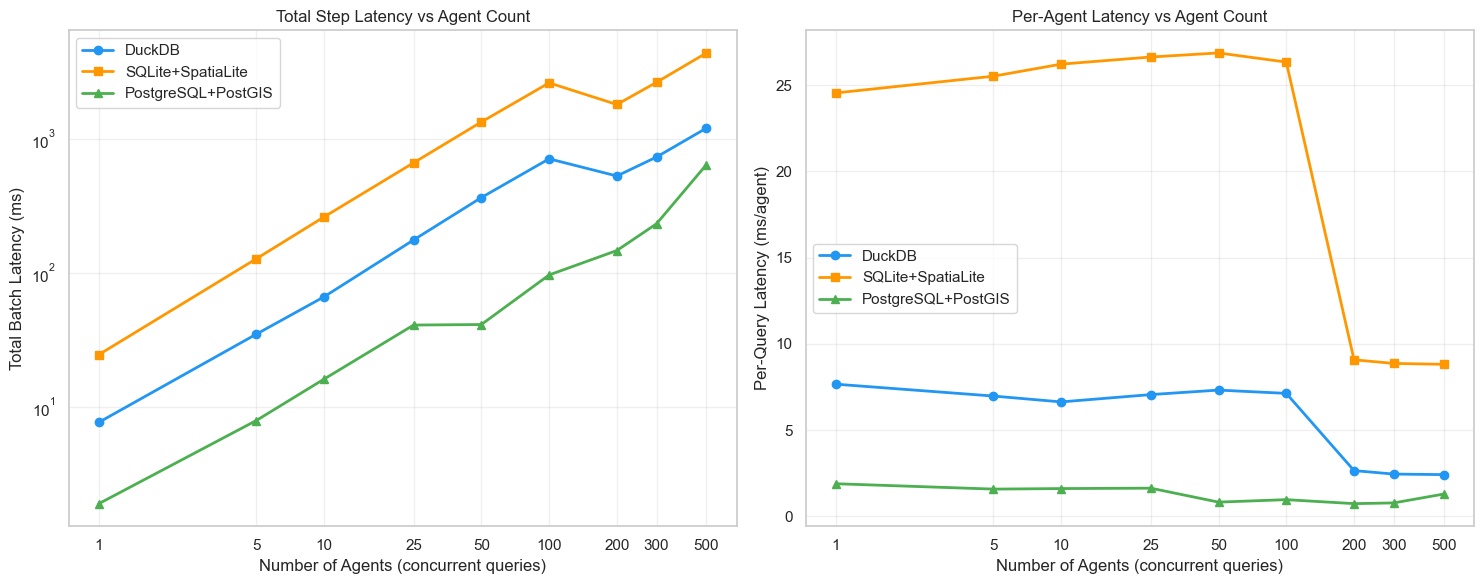

 Agents DuckDB (ms) SpatiaLite (ms) PostGIS (ms)
      1         7.7            24.5          1.9
      5        34.9           127.6          7.9
     10        66.3           262.2         16.1
     25       176.4           665.7         40.8
     50       365.9          1343.2         41.2
    100       712.8          2633.4         96.6
    200       530.3          1814.7        147.1
    300       735.0          2659.2        233.1
    500      1209.2          4405.8        645.4

--- At 500 agents (one simulation step) ---
DuckDB:      1209.2 ms  (157.9× vs 1 agent)
SpatiaLite:  4405.8 ms  (179.5× vs 1 agent)
PostGIS:      645.4 ms  (341.6× vs 1 agent)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = {'DuckDB': '#2196F3', 'SQLite+SpatiaLite': '#FF9800', 'PostgreSQL+PostGIS': '#4CAF50'}

# --- Left: Total batch latency ---
ax = axes[0]
ax.plot(AGENT_COUNTS, duck_batch, 'o-', color=colors['DuckDB'], label='DuckDB', linewidth=2, markersize=6)
ax.plot(AGENT_COUNTS, sqlite_batch, 's-', color=colors['SQLite+SpatiaLite'], label='SQLite+SpatiaLite', linewidth=2, markersize=6)
ax.plot(AGENT_COUNTS, pg_batch, '^-', color=colors['PostgreSQL+PostGIS'], label='PostgreSQL+PostGIS', linewidth=2, markersize=6)
ax.set_xlabel('Number of Agents (concurrent queries)')
ax.set_ylabel('Total Batch Latency (ms)')
ax.set_title('Total Step Latency vs Agent Count')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks(AGENT_COUNTS)
ax.set_xticklabels(AGENT_COUNTS)
ax.grid(True, alpha=0.3)

# --- Right: Per-query latency (total / n_agents) ---
ax2 = axes[1]
duck_per = [t / n for t, n in zip(duck_batch, AGENT_COUNTS)]
sqlite_per = [t / n for t, n in zip(sqlite_batch, AGENT_COUNTS)]
pg_per = [t / n for t, n in zip(pg_batch, AGENT_COUNTS)]

ax2.plot(AGENT_COUNTS, duck_per, 'o-', color=colors['DuckDB'], label='DuckDB', linewidth=2, markersize=6)
ax2.plot(AGENT_COUNTS, sqlite_per, 's-', color=colors['SQLite+SpatiaLite'], label='SQLite+SpatiaLite', linewidth=2, markersize=6)
ax2.plot(AGENT_COUNTS, pg_per, '^-', color=colors['PostgreSQL+PostGIS'], label='PostgreSQL+PostGIS', linewidth=2, markersize=6)
ax2.set_xlabel('Number of Agents (concurrent queries)')
ax2.set_ylabel('Per-Query Latency (ms/agent)')
ax2.set_title('Per-Agent Latency vs Agent Count')
ax2.legend()
ax2.set_xscale('log')
ax2.set_xticks(AGENT_COUNTS)
ax2.set_xticklabels(AGENT_COUNTS)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results_01_batch_latency.png', dpi=150)
plt.show()

# Summary table
batch_df = pd.DataFrame({
    'Agents': AGENT_COUNTS,
    'DuckDB (ms)': [f'{x:.1f}' for x in duck_batch],
    'SpatiaLite (ms)': [f'{x:.1f}' for x in sqlite_batch],
    'PostGIS (ms)': [f'{x:.1f}' for x in pg_batch],
})
print(batch_df.to_string(index=False))

# Crossover analysis
print(f'\n--- At 500 agents (one simulation step) ---')
print(f'DuckDB:    {duck_batch[-1]:>8.1f} ms  ({duck_batch[-1]/duck_batch[0]:>5.1f}× vs 1 agent)')
if not np.isnan(sqlite_batch[-1]):
    print(f'SpatiaLite:{sqlite_batch[-1]:>8.1f} ms  ({sqlite_batch[-1]/sqlite_batch[0]:>5.1f}× vs 1 agent)')
if not np.isnan(pg_batch[-1]):
    print(f'PostGIS:   {pg_batch[-1]:>8.1f} ms  ({pg_batch[-1]/pg_batch[0]:>5.1f}× vs 1 agent)')

In [8]:
# ── Export results for HTML report ──────────────────────────────────────
import os

os.makedirs('results', exist_ok=True)

def _clean(lst):
    return [None if (isinstance(v, float) and v != v) else v for v in lst]

export = {
    'single': {
        'DuckDB': duck_single,
        'SQLite+SpatiaLite': _clean(sqlite_single),
        'PostgreSQL+PostGIS': _clean(pg_single),
    },
    'medians': {c: float(plot_df[c].median()) for c in plot_df.columns},
    'p95s': {c: float(plot_df[c].quantile(0.95)) for c in plot_df.columns},
    'batch': {
        'agent_counts': AGENT_COUNTS,
        'DuckDB': duck_batch,
        'SQLite+SpatiaLite': _clean(sqlite_batch),
        'PostgreSQL+PostGIS': _clean(pg_batch),
    },
}

with open('results/01_database.json', 'w') as f:
    json.dump(export, f, indent=2)
print('Exported -> results/01_database.json')

Exported -> results/01_database.json
